<a href="https://colab.research.google.com/github/JoaoIvo15/Regressao-Multipla-Energy-Efficiency/blob/main/notebooks/03_diagnostico_e_selecao_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Diagnóstico e Seleção Final

Este notebook dá continuidade à etapa de modelagem realizada no Notebook 02 e tem como objetivo avaliar, por meio de procedimentos diagnósticos, a adequação das especificações candidatas para as respostas Y1 (Heating Load) e Y2 (Cooling Load).

A análise será concentrada nos resíduos dos modelos e nas observações potencialmente influentes, considerando aspectos como forma funcional, homocedasticidade, normalidade, independência dos erros e influência individual das observações.

A partir dos resultados diagnósticos, será realizada a seleção final das especificações para Y1 e Y2.

## 1. Configuração e preparação dos dados

Nesta etapa são importadas as bibliotecas necessárias e realizada a preparação da base de dados para reproduzir as especificações utilizadas no Notebook 02.

As variáveis X6 e X8 permanecem tratadas como categóricas, por meio de variáveis indicadoras, enquanto a dependência linear perfeita entre X2, X3 e X4 é respeitada na especificação dos modelos.

In [13]:
# Importa as bibliotecas e prepara a base para a análise diagnóstica.

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "JoaoIvo15/Regressao-Multipla-Energy-Efficiency/"
    "main/data/raw/ENB2012_data.xlsx"
)

df = pd.read_excel(DATA_URL)

df_model = pd.get_dummies(
    df,
    columns=["X6", "X8"],
    drop_first=True,
    dtype=int
)

variable_columns = {
    "X1": ["X1"],
    "X2": ["X2"],
    "X3": ["X3"],
    "X4": ["X4"],
    "X5": ["X5"],
    "X6": ["X6_3", "X6_4", "X6_5"],
    "X7": ["X7"],
    "X8": ["X8_1", "X8_2", "X8_3", "X8_4", "X8_5"]
}

def fit_mrlm(response, variables):
    columns = []
    for variable in variables:
        columns.extend(variable_columns[variable])

    X = sm.add_constant(df_model[columns])
    y = df_model[response]

    return sm.OLS(y, X).fit()

## 2. Modelos candidatos

A partir dos resultados obtidos no Notebook 02, foram selecionadas especificações candidatas para cada variável resposta, representando diferentes compromissos entre qualidade de ajuste, complexidade e controle da multicolinearidade.

Para Y1 (Heating Load), serão avaliados os Modelos 144, 143, 142 e 122.

Para Y2 (Cooling Load), serão avaliados os Modelos 156, 113, 81 e 17.

Essas especificações serão mantidas durante a etapa diagnóstica, permitindo uma comparação sistemática quanto à adequação dos resíduos e à presença de observações potencialmente influentes. A escolha final será realizada após a análise conjunta desses resultados.

In [14]:
# Define e estima os modelos candidatos para Y1 e Y2.

model_candidates = {
    "Y1": {
        "M144": ["X1", "X3", "X4", "X5", "X7", "X8"],
        "M143": ["X1", "X4", "X5", "X7", "X8"],
        "M142": ["X1", "X3", "X5", "X7", "X8"],
        "M122": ["X3", "X5", "X7", "X8"]
    },
    "Y2": {
        "M156": ["X1", "X3", "X4", "X5", "X7", "X8"],
        "M113": ["X1", "X4", "X5", "X7"],
        "M81": ["X1", "X3", "X5", "X7"],
        "M17": ["X1", "X5", "X7"]
    }
}

fitted_models = {
    response: {
        model_name: fit_mrlm(response, variables)
        for model_name, variables in candidates.items()
    }
    for response, candidates in model_candidates.items()
}

In [15]:
# Resume as especificações e o número de parâmetros dos modelos candidatos.

candidate_table = []

for response, models in model_candidates.items():
    for model_name, variables in models.items():
        model = fitted_models[response][model_name]

        candidate_table.append({
            "Resposta": response,
            "Modelo": model_name,
            "Preditores": " + ".join(variables),
            "Parâmetros": int(len(model.params)),
            "R² ajustado": model.rsquared_adj,
            "AIC": model.aic,
            "BIC": model.bic,
            "RMSE": np.sqrt(np.mean(model.resid ** 2))
        })

candidate_table = pd.DataFrame(candidate_table)

candidate_table

,Resposta,Modelo,Preditores,Parâmetros,R² ajustado,AIC,BIC,RMSE
0,Y1,M144,X1 + X3 + X4 + X5 + X7 + X8,11,0.923058,3771.278186,3822.359873,2.778741
1,Y1,M143,X1 + X4 + X5 + X7 + X8,10,0.922681,3774.054170,3820.492068,2.787394
2,Y1,M142,X1 + X3 + X5 + X7 + X8,10,0.920244,3797.879301,3844.317198,2.830967
3,Y1,M122,X3 + X5 + X7 + X8,9,0.917814,3819.945616,3861.739724,2.875672
4,Y2,M156,X1 + X3 + X4 + X5 + X7 + X8,11,0.888344,3966.830398,4017.912085,3.156016
5,Y2,M113,X1 + X4 + X5 + X7,5,0.885518,3980.094608,4003.313557,3.208355
6,Y2,M81,X1 + X3 + X5 + X7,5,0.883638,3992.603178,4015.822127,3.234590
7,Y2,M17,X1 + X5 + X7,4,0.881489,4005.658723,4024.233882,3.266450


## 3. Diagnóstico dos resíduos

A análise dos resíduos tem como objetivo verificar se as especificações candidatas atendem às principais condições necessárias para a adequação do modelo de regressão linear.

Serão avaliados, de forma complementar, a relação entre resíduos e valores ajustados, a homocedasticidade, a normalidade dos resíduos e a independência dos erros.

Nenhum diagnóstico isolado será utilizado como critério único para a seleção final. A decisão será baseada na avaliação conjunta das evidências obtidas para cada modelo candidato.

### 3.1 Resíduos versus valores ajustados

O gráfico de resíduos versus valores ajustados permite avaliar visualmente a adequação da forma funcional do modelo e identificar padrões sistemáticos nos erros.

Em uma especificação adequada, espera-se que os resíduos estejam distribuídos de maneira aproximadamente aleatória ao redor de zero, sem tendência, curvatura ou alteração sistemática da dispersão ao longo dos valores ajustados.

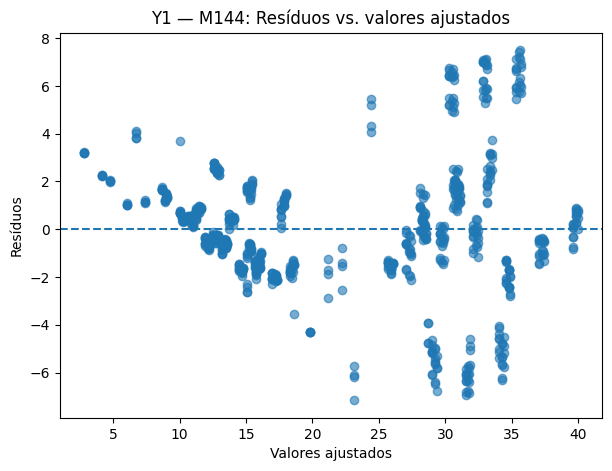

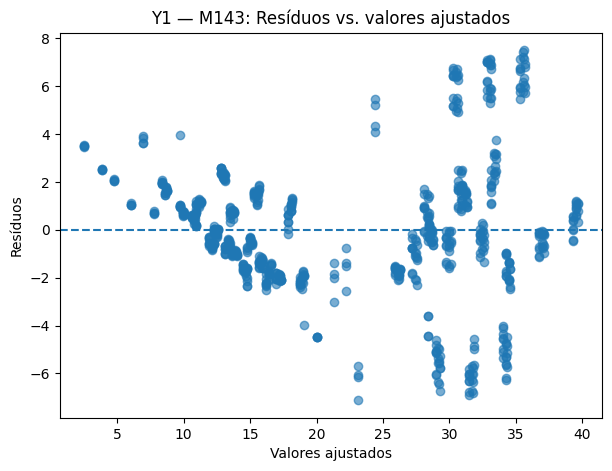

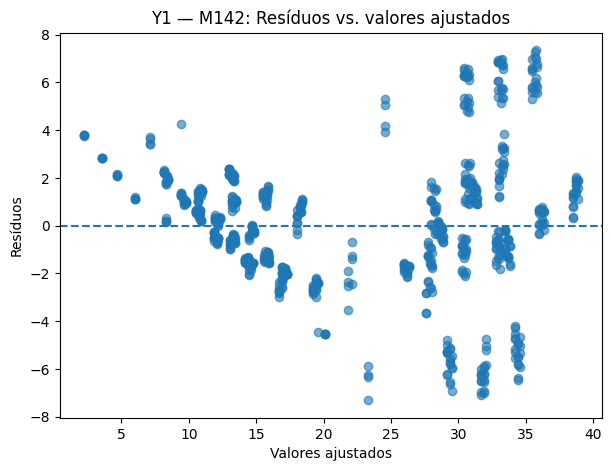

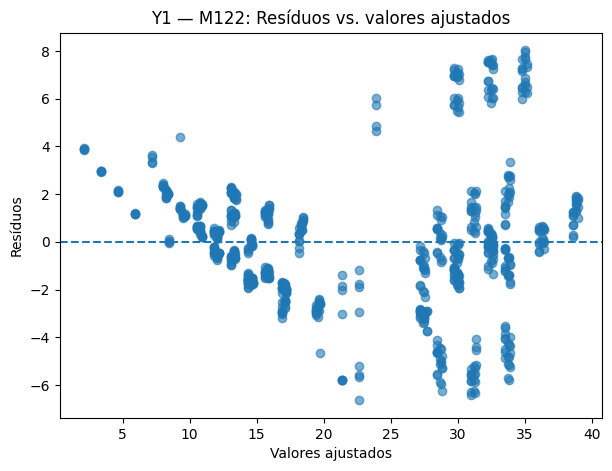

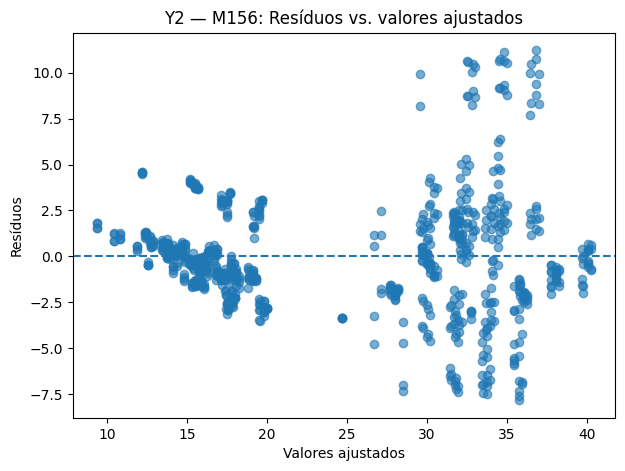

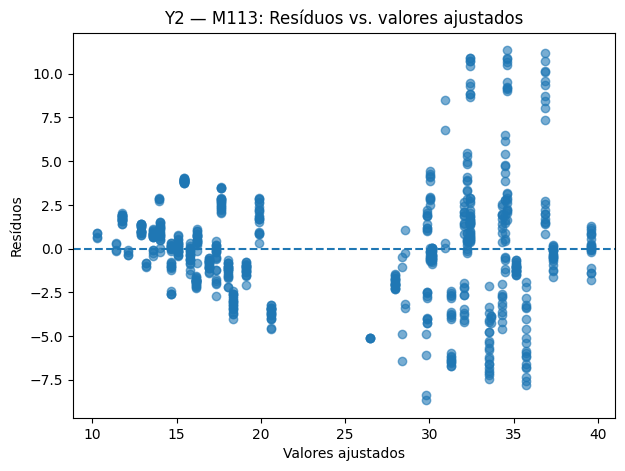

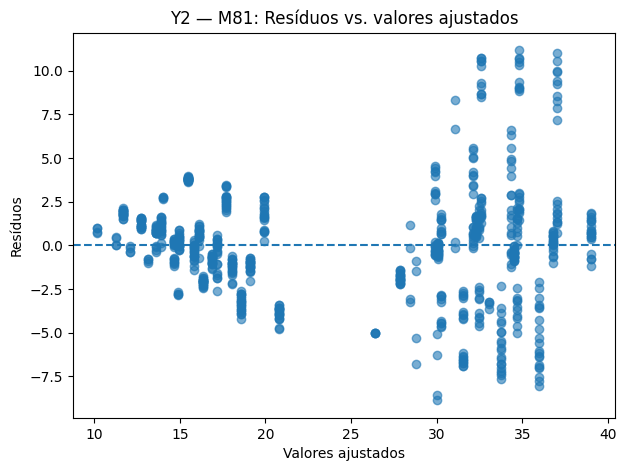

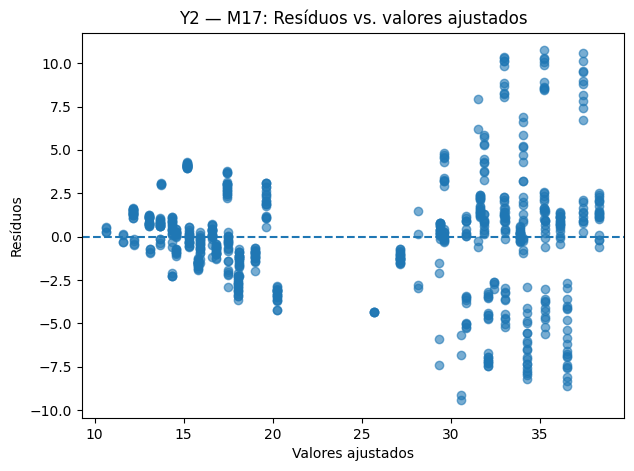

In [16]:
# Gera os gráficos de resíduos versus valores ajustados para todos os modelos candidatos.

for response, models in fitted_models.items():
    for model_name, model in models.items():
        plt.figure(figsize=(7, 5))
        plt.scatter(model.fittedvalues, model.resid, alpha=0.6)
        plt.axhline(0, linestyle="--")
        plt.xlabel("Valores ajustados")
        plt.ylabel("Resíduos")
        plt.title(f"{response} — {model_name}: Resíduos vs. valores ajustados")
        plt.show()

### 3.2 Testes de homocedasticidade

A inspeção dos gráficos de resíduos versus valores ajustados revelou padrões compatíveis com heterocedasticidade, caracterizados por alterações na dispersão dos resíduos ao longo dos valores ajustados. Dessa forma, a hipótese de variância constante dos erros deve ser investigada formalmente.

Para complementar a análise gráfica, foram aplicados os testes de Breusch-Pagan e de White aos oito modelos candidatos.

Em ambos os testes, a hipótese nula é a existência de homocedasticidade, enquanto a hipótese alternativa corresponde à presença de heterocedasticidade.

Considerando o nível de significância de 5%, valores de p inferiores a 0,05 fornecem evidências para rejeitar a hipótese nula. Os resultados dos dois testes serão avaliados conjuntamente, de modo a verificar a consistência da evidência de heterocedasticidade entre as diferentes especificações.

In [17]:
# Testa formalmente a homocedasticidade e resume as conclusões para cada modelo.

from statsmodels.stats.diagnostic import het_breuschpagan, het_white

alpha = 0.05
hetero_results = []

for response, models in fitted_models.items():
    for model_name, model in models.items():
        bp = het_breuschpagan(
            model.resid,
            model.model.exog
        )

        white = het_white(
            model.resid,
            model.model.exog
        )

        bp_pvalue = bp[1]
        white_pvalue = white[1]

        hetero_results.append({
            "Resposta": response,
            "Modelo": model_name,
            "BP — p-valor LM": bp_pvalue,
            "BP — p-valor F": bp[3],
            "White — p-valor LM": white_pvalue,
            "White — p-valor F": white[3],
            "BP": "Heterocedasticidade" if bp_pvalue < alpha else "Não rejeita H₀",
            "White": "Heterocedasticidade" if white_pvalue < alpha else "Não rejeita H₀"
        })

hetero_results = pd.DataFrame(hetero_results)

hetero_results

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:1272: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols = OLS(y**2, exog).fit()
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:1272: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols = OLS(y**2, exog).fit()
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:1272: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols = OLS(y**2, exog).fit()
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:1272: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols = OLS(y**2, exog).fit()
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:1272: SingularMatrixWarning: The design matr

,Resposta,Modelo,BP — p-valor LM,BP — p-valor F,White — p-valor LM,White — p-valor F,BP,White
0,Y1,M144,5.894312e-75,3.590845e-104,9.197053e-117,0.000000e+00,Heterocedasticidade,Heterocedasticidade
1,Y1,M143,4.357218e-75,8.695881e-104,1.711488e-118,1.063397e-304,Heterocedasticidade,Heterocedasticidade
2,Y1,M142,3.258989e-73,3.459203e-100,2.220215e-106,8.557825e-231,Heterocedasticidade,Heterocedasticidade
3,Y1,M122,4.006526e-24,1.927079e-26,3.798256e-43,6.507224e-55,Heterocedasticidade,Heterocedasticidade
4,Y2,M156,1.191196e-42,9.266851e-51,9.641509e-53,3.722622e-76,Heterocedasticidade,Heterocedasticidade
5,Y2,M113,1.554533e-44,6.007670e-52,5.997520e-69,7.387802e-94,Heterocedasticidade,Heterocedasticidade
6,Y2,M81,4.546605e-41,2.964431e-47,3.931764e-62,4.466733e-82,Heterocedasticidade,Heterocedasticidade
7,Y2,M17,4.332031e-32,1.615343e-35,6.252807e-34,1.222471e-38,Heterocedasticidade,Heterocedasticidade


In [18]:
# Resume a decisão conjunta dos testes de Breusch-Pagan e White.

summary_hetero = []

for _, row in hetero_results.iterrows():
    bp_reject = row["BP — p-valor LM"] < alpha
    white_reject = row["White — p-valor LM"] < alpha

    if bp_reject and white_reject:
        conclusion = "Evidência consistente de heterocedasticidade"
    elif bp_reject or white_reject:
        conclusion = "Evidência parcial de heterocedasticidade"
    else:
        conclusion = "Sem evidência suficiente de heterocedasticidade"

    summary_hetero.append({
        "Resposta": row["Resposta"],
        "Modelo": row["Modelo"],
        "Conclusão": conclusion
    })

summary_hetero = pd.DataFrame(summary_hetero)

summary_hetero

,Resposta,Modelo,Conclusão
0,Y1,M144,Evidência consistente de heterocedasticidade
1,Y1,M143,Evidência consistente de heterocedasticidade
2,Y1,M142,Evidência consistente de heterocedasticidade
3,Y1,M122,Evidência consistente de heterocedasticidade
4,Y2,M156,Evidência consistente de heterocedasticidade
5,Y2,M113,Evidência consistente de heterocedasticidade
6,Y2,M81,Evidência consistente de heterocedasticidade
7,Y2,M17,Evidência consistente de heterocedasticidade


#### Interpretação

Os resultados confirmam formalmente a evidência observada nos gráficos. Para todos os modelos candidatos, os testes de Breusch-Pagan e de White apresentaram valores de p inferiores a 0,05, levando à rejeição da hipótese nula de homocedasticidade.

A concordância entre os dois procedimentos indica evidência consistente de heterocedasticidade nas oito especificações analisadas. Esse resultado implica que a variância dos erros não pode ser considerada constante e deverá ser levada em consideração nas etapas posteriores de inferência e seleção do modelo final.

### 3.3 Normalidade dos resíduos

A normalidade dos resíduos será avaliada por meio de uma abordagem gráfica e de um teste estatístico formal.

Inicialmente, serão utilizados gráficos Quantile-Quantile (QQ-plots), que permitem comparar os quantis observados dos resíduos com os quantis esperados de uma distribuição normal. Em uma situação compatível com a normalidade, espera-se que os pontos se distribuam aproximadamente ao longo da reta de referência.

Como complemento à análise gráfica, será aplicado o teste de Jarque-Bera, cuja hipótese nula corresponde à normalidade dos resíduos. O teste considera conjuntamente a assimetria e a curtose da distribuição residual.

A interpretação será realizada em conjunto com os QQ-plots, considerando também o tamanho amostral. Dessa forma, eventuais desvios estatisticamente significativos da normalidade serão avaliados quanto à sua magnitude e ao seu comportamento gráfico, evitando que o resultado de um único teste determine isoladamente a avaliação dos modelos.

#### 3.3.1 Avaliação gráfica

Os QQ-plots serão utilizados para verificar visualmente o grau de aderência dos resíduos à distribuição normal, com atenção especial aos desvios nas caudas e à presença de padrões sistemáticos ao longo da reta de referência.

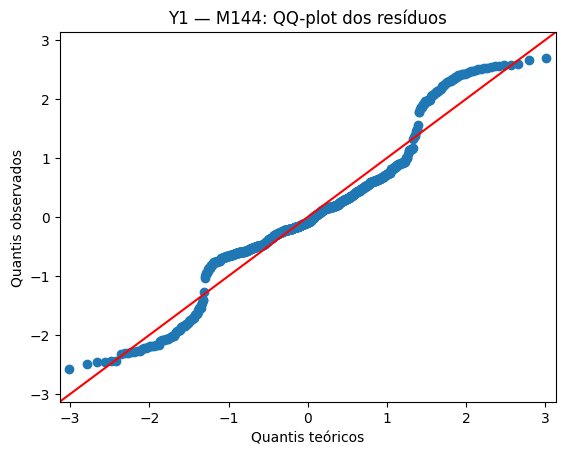

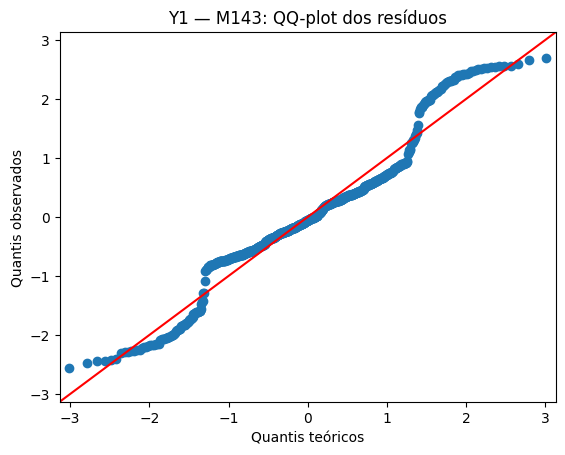

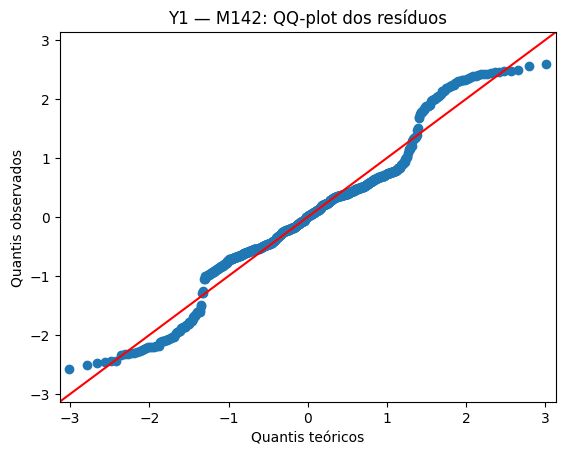

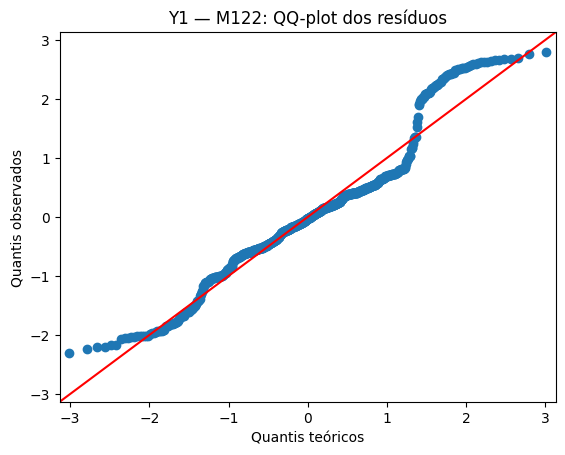

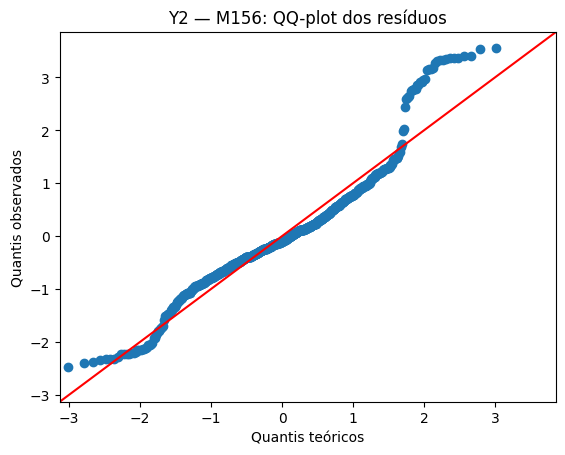

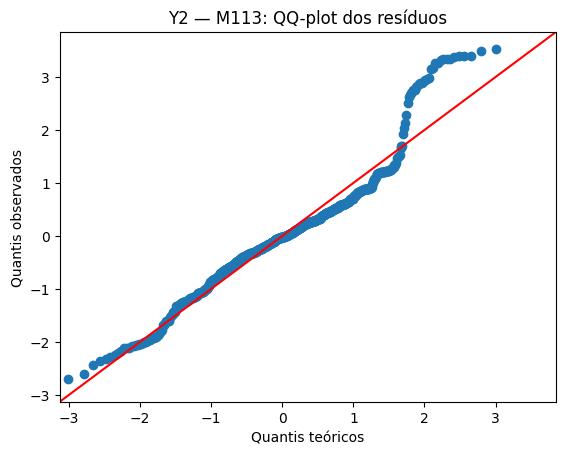

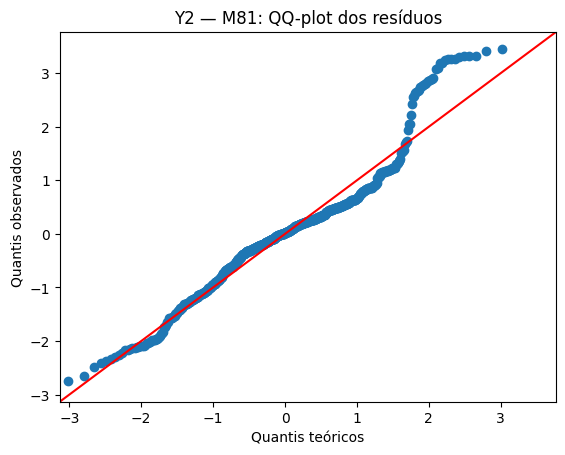

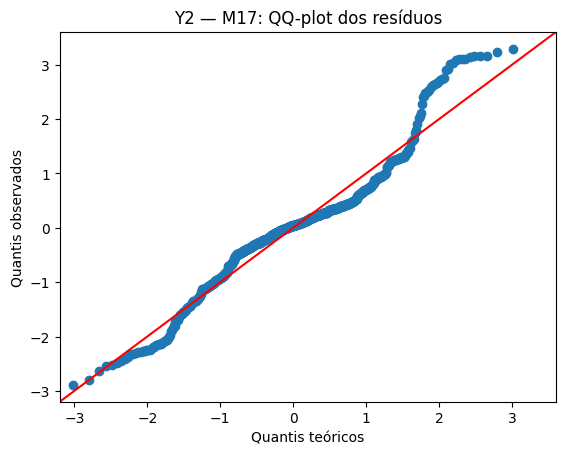

In [19]:
# Gera QQ-plots dos resíduos para todos os modelos candidatos.

for response, models in fitted_models.items():
    for model_name, model in models.items():
        fig = sm.qqplot(
            model.resid,
            line="45",
            fit=True
        )

        plt.title(f"{response} — {model_name}: QQ-plot dos resíduos")
        plt.xlabel("Quantis teóricos")
        plt.ylabel("Quantis observados")
        plt.show()

#### 3.3.2 Teste de Jarque-Bera

A avaliação gráfica é complementada pelo teste de Jarque-Bera, que verifica conjuntamente a assimetria e a curtose dos resíduos.

As hipóteses são:

$$
H_0:\text{os resíduos seguem distribuição normal}
$$

$$
H_1:\text{os resíduos não seguem distribuição normal}
$$


Adotando nível de significância de 5%, valores de p inferiores a 0,05 levam à rejeição da hipótese de normalidade.

In [21]:
# Aplica o teste de Jarque-Bera e obtém assimetria e curtose dos resíduos.

from statsmodels.stats.stattools import jarque_bera

normality_results = []

for response, models in fitted_models.items():
    for model_name, model in models.items():
        jb_stat, jb_pvalue, skewness, kurtosis = jarque_bera(
            model.resid
        )

        normality_results.append({
            "Resposta": response,
            "Modelo": model_name,
            "JB": jb_stat,
            "p-valor": jb_pvalue,
            "Assimetria": skewness,
            "Curtose": kurtosis,
            "Conclusão": (
                "Rejeita normalidade"
                if jb_pvalue < 0.05
                else "Não rejeita normalidade"
            )
        })

normality_results = pd.DataFrame(normality_results)

normality_results

,Resposta,Modelo,JB,p-valor,Assimetria,Curtose,Conclusão
0,Y1,M144,33.116117,6.440605e-08,0.229283,3.908073,Rejeita normalidade
1,Y1,M143,29.944586,3.144965e-07,0.235747,3.844666,Rejeita normalidade
2,Y1,M142,13.391260,1.236303e-03,0.088150,3.622411,Rejeita normalidade
3,Y1,M122,57.376977,3.473344e-13,0.521647,3.839385,Rejeita normalidade
4,Y2,M156,245.277948,5.477347e-54,0.803183,5.254889,Rejeita normalidade
5,Y2,M113,204.987051,3.073459e-45,0.702449,5.105256,Rejeita normalidade
6,Y2,M81,151.963658,1.003485e-33,0.548770,4.882623,Rejeita normalidade
7,Y2,M17,97.514174,6.684457e-22,0.294268,4.643455,Rejeita normalidade


#### 3.3.3 Interpretação

A inspeção dos QQ-plots revelou desvios da distribuição normal, especialmente nas caudas dos resíduos. Esse comportamento foi confirmado pelo teste de Jarque-Bera, que apresentou valores de p inferiores a 0,05 para todos os oito modelos candidatos.

Dessa forma, ao nível de significância de 5%, rejeita-se a hipótese de normalidade dos resíduos em todas as especificações avaliadas.

Os resultados de assimetria e curtose ajudam a caracterizar esse desvio. Todos os modelos apresentaram assimetria positiva, indicando maior concentração de desvios em uma das caudas da distribuição, enquanto os valores de curtose foram superiores a 3 em todas as especificações, indicando caudas mais pesadas do que as esperadas sob uma distribuição normal.

Para Y1, os desvios da normalidade foram relativamente menores, com destaque para o Modelo 142, que apresentou a menor estatística de Jarque-Bera entre os candidatos dessa resposta. Para Y2, os desvios foram mais acentuados, com estatísticas de Jarque-Bera consideravelmente maiores.

Assim como observado na análise de heterocedasticidade, a ausência de normalidade dos resíduos será considerada conjuntamente com os demais diagnósticos e não será utilizada, de forma isolada, como critério de exclusão dos modelos.

### 3.4 Independência dos resíduos

A independência dos erros constitui uma condição importante da regressão linear, mas sua avaliação deve considerar a estrutura de coleta e organização dos dados.

Como as observações da base não correspondem a uma série temporal, a ordem das linhas não possui, por si só, interpretação temporal. Dessa forma, testes de autocorrelação baseados exclusivamente na posição sequencial das observações devem ser interpretados com cautela e não serão utilizados isoladamente para estabelecer a adequação dos modelos.

Nesta etapa, será realizada uma inspeção gráfica dos resíduos em função da ordem das observações, buscando identificar agrupamentos ou padrões sistemáticos que possam indicar dependência não explicada pelo modelo. Essa avaliação será considerada conjuntamente com a estrutura dos dados e com os demais diagnósticos.

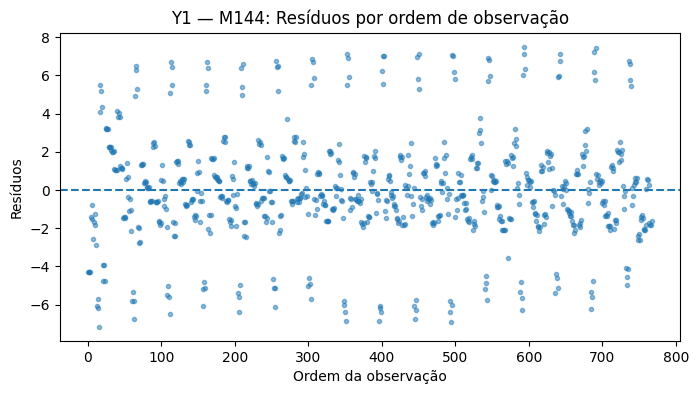

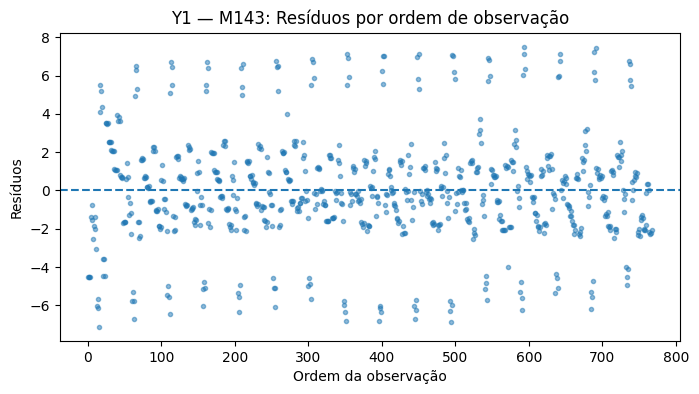

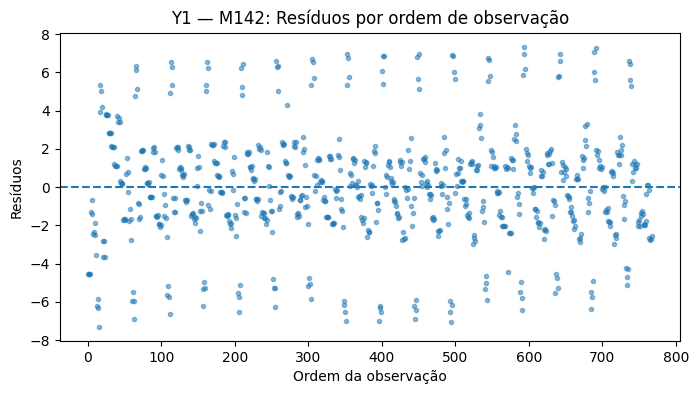

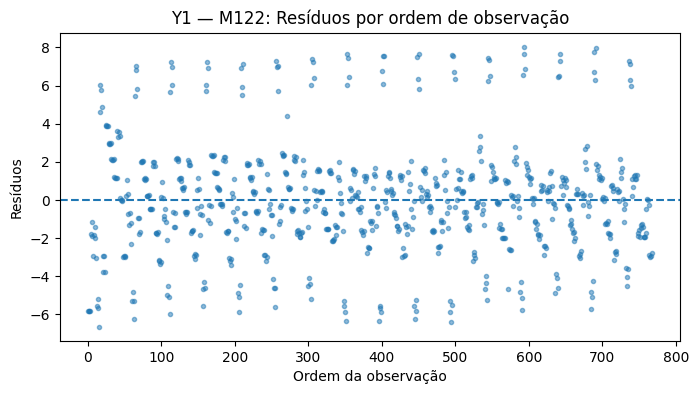

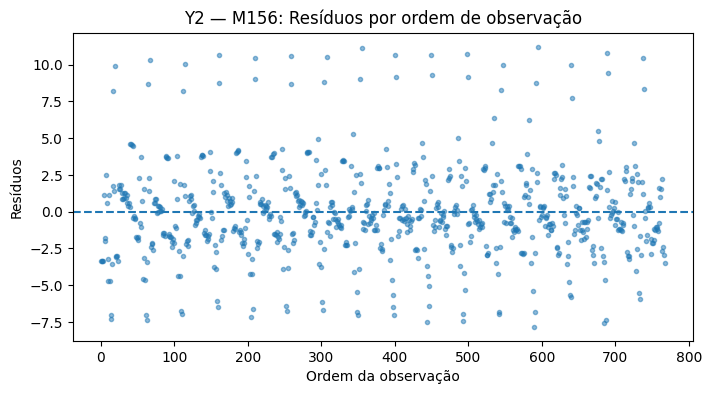

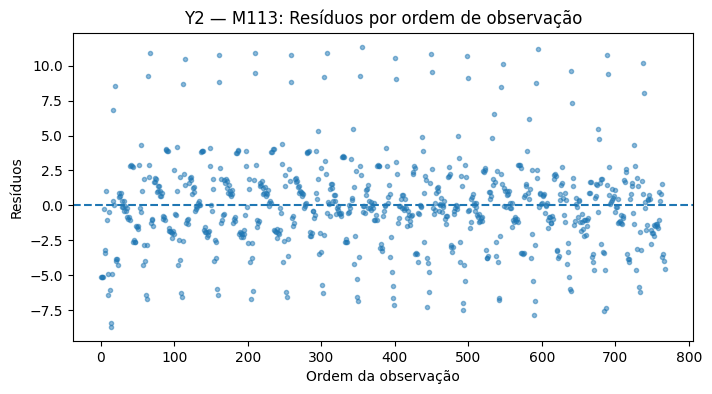

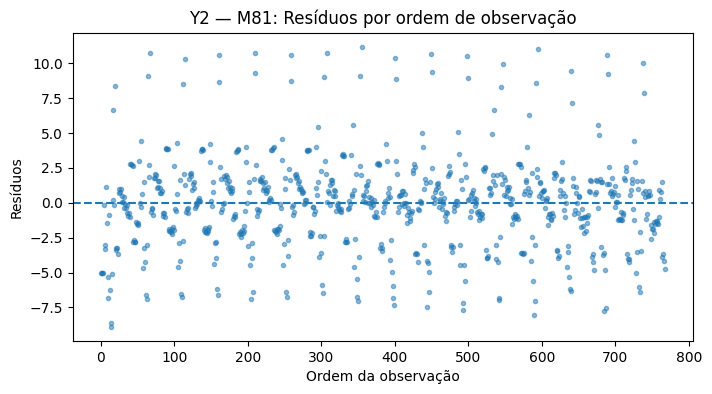

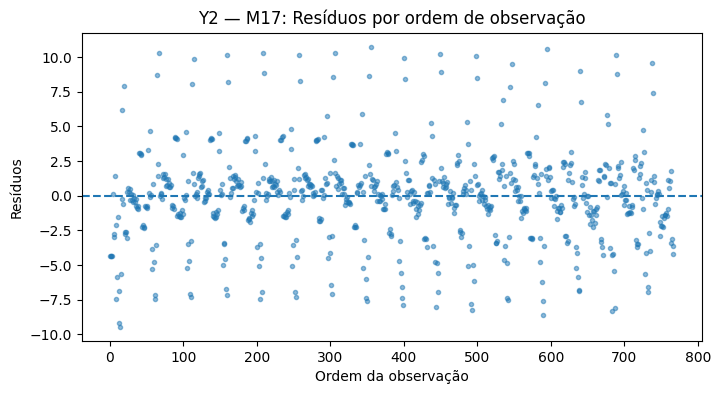

In [22]:
# Gera os resíduos em função da ordem das observações para avaliar possíveis padrões de dependência.

for response, models in fitted_models.items():
    for model_name, model in models.items():
        plt.figure(figsize=(8, 4))
        plt.plot(
            np.arange(len(model.resid)),
            model.resid,
            marker=".",
            linestyle="none",
            alpha=0.5
        )
        plt.axhline(0, linestyle="--")
        plt.xlabel("Ordem da observação")
        plt.ylabel("Resíduos")
        plt.title(f"{response} — {model_name}: Resíduos por ordem de observação")
        plt.show()

#### 3.4.1 Interpretação

A inspeção dos resíduos em função da ordem das observações não revelou tendências sistemáticas, sequências prolongadas de resíduos com o mesmo sinal ou padrões cíclicos que sugerissem dependência entre os erros.

Embora a ordem das observações não possua interpretação temporal na base analisada, a inspeção gráfica fornece evidência complementar de que não há um padrão evidente de dependência residual ao longo da sequência das observações.

Assim, considerando conjuntamente a estrutura dos dados e a ausência de padrões sistemáticos nos gráficos, os resíduos são considerados compatíveis com a hipótese de independência para fins da presente modelagem.

### 3.5 Avaliação da forma funcional

A adequação da forma funcional do modelo será avaliada para verificar se a especificação linear adotada é compatível com a relação entre as variáveis explicativas e a variável resposta.

Embora a análise dos resíduos versus valores ajustados já permita identificar possíveis padrões de curvatura ou estrutura sistemática, será utilizado adicionalmente o teste de Ramsey RESET como procedimento formal de diagnóstico.

O teste avalia se a inclusão de potências dos valores ajustados fornece evidência de variáveis ou termos não lineares omitidos na especificação original. A hipótese nula corresponde à adequação da forma funcional especificada, enquanto a hipótese alternativa indica possível erro de especificação.

Como os modelos apresentaram heterocedasticidade na etapa anterior, a interpretação do teste será realizada com cautela, sendo considerada conjuntamente com a análise gráfica dos resíduos.

#### 3.5.1 Teste de Ramsey RESET

No teste de Ramsey RESET, considera-se como hipótese nula que a forma funcional especificada para o modelo é adequada:

$$
H_0:\text{forma funcional corretamente especificada}
$$

contra a hipótese alternativa:

$$
H_1:\text{há evidência de erro de especificação na forma funcional}
$$

O teste será aplicado utilizando uma potência adicional dos valores ajustados, permitindo verificar se termos não lineares adicionais fornecem poder explicativo estatisticamente significativo.

Ao nível de significância de 5%, valores de p inferiores a 0,05 fornecem evidência para rejeitar a hipótese nula de adequação da especificação.

In [23]:
# Aplica o teste de Ramsey RESET com inferência robusta à heterocedasticidade.

from statsmodels.stats.diagnostic import linear_reset

reset_results = []

for response, models in fitted_models.items():
    for model_name, model in models.items():
        reset = linear_reset(
            model,
            power=3,
            test_type="fitted",
            use_f=False,
            cov_type="HC3"
        )

        reset_results.append({
            "Resposta": response,
            "Modelo": model_name,
            "RESET — estatística": reset.statistic,
            "RESET — p-valor": reset.pvalue,
            "Conclusão": (
                "Possível erro de especificação"
                if reset.pvalue < 0.05
                else "Sem evidência de erro de especificação"
            )
        })

reset_results = pd.DataFrame(reset_results)

reset_results

,Resposta,Modelo,RESET — estatística,RESET — p-valor,Conclusão
0,Y1,M144,89.834166,3.109987e-20,Possível erro de especificação
1,Y1,M143,114.291510,1.520246e-25,Possível erro de especificação
2,Y1,M142,164.038128,2.396476e-36,Possível erro de especificação
3,Y1,M122,192.366174,1.691282e-42,Possível erro de especificação
4,Y2,M156,42.652680,5.471271e-10,Possível erro de especificação
5,Y2,M113,63.406531,1.703910e-14,Possível erro de especificação
6,Y2,M81,79.851676,4.575398e-18,Possível erro de especificação
7,Y2,M17,32.293143,9.719256e-08,Possível erro de especificação


#### 3.5.2 Interpretação

Os resultados do teste de Ramsey RESET forneceram evidências estatisticamente significativas de inadequação da forma funcional para todos os modelos candidatos.

Em todas as oito especificações, os valores de p foram inferiores a 0,05, levando à rejeição da hipótese nula de adequação da forma funcional. Esse resultado indica que a especificação linear atualmente adotada pode não representar de forma suficiente a relação entre os preditores e as variáveis resposta.

Entre os modelos avaliados, o Y1 — M144 apresentou a menor estatística do teste RESET entre os candidatos de Y1, enquanto o Y2 — M17 apresentou a menor estatística entre os candidatos de Y2. Entretanto, mesmo essas especificações apresentaram valores de p muito inferiores ao nível de significância de 5%, não havendo evidência suficiente para considerar qualquer dos modelos adequadamente especificado segundo o teste.

O teste de Ramsey RESET possui caráter geral e não identifica, isoladamente, qual termo ou transformação deveria ser incorporado ao modelo. Assim, a rejeição da hipótese nula não implica necessariamente que uma forma quadrática ou outra transformação específica seja a solução. O resultado será considerado conjuntamente com os demais diagnósticos antes da definição da especificação final.

### 3.6 Diagnóstico de observações influentes

Mesmo quando um modelo apresenta medidas de ajuste satisfatórias, determinadas observações podem exercer influência desproporcional sobre a estimação dos coeficientes. A identificação dessas observações é importante para avaliar a estabilidade das especificações candidatas e verificar se os resultados dependem excessivamente de um pequeno conjunto de casos.

Nesta etapa serão avaliados três aspectos complementares: leverage, resíduos studentizados e distância de Cook.

O leverage mede o grau de afastamento de uma observação em relação ao centro da configuração dos preditores. Os resíduos studentizados permitem identificar observações com discrepâncias elevadas em relação ao comportamento esperado pelo modelo. A distância de Cook combina informações sobre resíduos e leverage para avaliar a influência global de cada observação sobre as estimativas do modelo.

Os critérios utilizados serão tratados como referências diagnósticas, e não como regras automáticas de exclusão de observações. Uma observação potencialmente influente será investigada em conjunto com sua posição nos demais diagnósticos e com a estrutura dos dados.

#### 3.6.1 Leverage

O leverage, ou valor de alavancagem, quantifica o quão distante uma observação está da configuração central das variáveis explicativas.

Valores elevados indicam observações com maior potencial para influenciar a estimação dos coeficientes. Como referência diagnóstica, será utilizado o limite $2p/n$, em que $p$ corresponde ao número de parâmetros estimados, incluindo o intercepto, e $n$ corresponde ao tamanho da amostra.

Esse limite é utilizado apenas como regra de referência para investigação de possíveis observações de alta alavancagem.